In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
import os

In [2]:
import cv2 
import os 

In [3]:
import matplotlib.pyplot as plt


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

Found 0 images belonging to 0 classes.


IndexError: index 0 is out of bounds for axis 0 with size 0

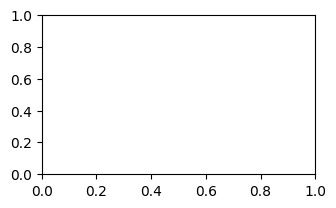

In [5]:
def dataset_train_processing():
    # Hardcode dataset path
    data_path =r'C:\SumMe\Frame\Car rail crossing'
    augmented_data_path = r'C:\SumMe\Augmentation\Augcr\Aug'
    
    # Create the directory for augmented data if it doesn't exist
    if not os.path.exists(augmented_data_path):
        os.makedirs(augmented_data_path)
    
    # Process dataset
    file_names = os.listdir(data_path)
    
    # Set a datagenerator for augmentation
    train_datagen = ImageDataGenerator(rotation_range=15,
                                       shear_range=0.1,
                                       zoom_range=0.2,
                                       horizontal_flip=True,
                                       width_shift_range=0.1,
                                       height_shift_range=0.1)
    
    # Create batches of data for augmentation
    for file_name in file_names:
        image_path = os.path.join(data_path, file_name)
        img = plt.imread(image_path)
        img = img.reshape((1,) + img.shape)  # Reshape to add batch dimension
        
        # Flow the image through the generator and save augmented images
        i = 0
        for batch in train_datagen.flow(img, 
                                        batch_size=1,
                                        save_to_dir=augmented_data_path,
                                        save_prefix=f'aug_{os.path.splitext(file_name)[0]}',
                                        save_format='jpeg'):
            i += 1
            if i >= 1:  # Save 2 augmented versions of each image
                break
    
    # Sample visualization of augmented images (optional)
    example_gen = train_datagen.flow_from_directory(data_path,
                                                    target_size=(224, 224),
                                                    batch_size=1,
                                                    class_mode=None,
                                                    save_to_dir=augmented_data_path,
                                                    save_prefix='aug_example',
                                                    save_format='jpg')
    
    plt.figure(figsize=(12, 12))
    for i in range(0, 15):
        plt.subplot(5, 3, i + 1)
        for X in example_gen:
            image = X[0]
            plt.imshow(image)
            break
    plt.tight_layout()
    plt.show()

# Usage
dataset_train_processing()

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
import numpy as np
import os

# Load the InceptionV3 model
net = InceptionV3(include_top=True, weights='imagenet')
net.summary()

# Load images from directory using ImageDataGenerator
image_directory = r'C:\SumMe\Augmentation\Augcr'
input_size = net.input_shape[1:3]  # Get the input size (height, width)

datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
# Create a data generator for the images
augimds = datagen.flow_from_directory(image_directory,
                                      target_size=input_size,
                                      batch_size=32,  # Adjust the batch size if needed
                                      class_mode=None,
                                      shuffle=False) 

# Create a model that outputs the activations from the specified layer
layer_name = 'predictions'  # Example layer name in InceptionV3 (change as needed)
intermediate_layer_model = tf.keras.Model(inputs=net.input,
                                          outputs=net.get_layer(layer_name).output)

# Generate activations
features_train = intermediate_layer_model.predict(augimds)
# Reshape the features to ensure they are in 'rows' format (2D)
features_train = features_train.reshape(features_train.shape[0], -1)
np.save(os.path.join(image_directory, 'inceptionv3_features_train.npy'), features_train)

print(f"Features shape: {features_train.shape}")

# Print some sample features
print("Sample features (first 5 rows):")
print(features_train[:5])

Model: "inception_v3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 299, 299, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 149, 149, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 149, 149, 32  96         ['conv2d[0][0]']                 
 alization)                     )                                                      

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
import os


# Load the ResNet50 model
net = ResNet50(include_top=True, weights='imagenet')
net.summary()

# Load images from directory using ImageDataGenerator
image_directory = r'C:\SumMe\Augmentation\Augcr'
input_size = net.input_shape[1:3]  # Get the input size (height, width)

datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
# Create a data generator for the images
augimds = datagen.flow_from_directory(image_directory,
                                      target_size=input_size,
                                      batch_size=32,  # Adjust the batch size if needed
                                      class_mode=None,
                                      shuffle=False) 

# Generate activations
features_train = intermediate_layer_model.predict(augimds)
# Create a model that outputs the activations from the specified layer
layer_name = 'predictions'  # Example layer name in ResNet50
intermediate_layer_model = tf.keras.Model(inputs=net.input,
                                          outputs=net.get_layer(layer_name).output)

# Generate activations
features_train = intermediate_layer_model.predict(augimds)
# Reshape the features to ensure they are in 'rows' format (2D)
features_train = features_train.reshape(features_train.shape[0], -1)
np.save(os.path.join(image_directory, 'resnet50_features_train.npy'), features_train)


print(f"Features shape: {features_train.shape}")

# Print some sample features
print("Sample features (first 5 rows):")
print(features_train[:5])

Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_2[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                           

In [3]:
import numpy as np
import os

# Define the directory where your features are saved
image_directory = r'C:\SumMe\Augmentation\Augcr'

# Load the features from the saved .npy files
features_resnet = np.load(os.path.join(image_directory, 'resnet50_features_train.npy'))
features_inceptionv3 = np.load(os.path.join(image_directory, 'inceptionv3_features_train.npy'))

# Ensure both feature arrays have the same number of samples
assert features_resnet.shape[0] == features_inceptionv3.shape[0], "Number of samples must be the same in both feature arrays."

# Concatenate the features along the feature dimension (axis=1)
features_combined = np.concatenate((features_resnet, features_inceptionv3), axis=1)

# Save the combined features to a new .npy file
np.save(os.path.join(image_directory, 'combined_features_train.npy'), features_combined)

print(f"Combined features shape: {features_combined.shape}")

# Print some sample combined features
print("Sample combined features (first 5 rows):")
print(features_combined[:5])

Combined features shape: (5075, 2000)
Sample combined features (first 5 rows):
[[2.2658041e-07 3.1640269e-07 1.0179759e-05 ... 1.5615786e-05
  3.3358596e-05 5.6121451e-05]
 [2.1812534e-06 4.8280422e-06 5.3343178e-06 ... 1.0794843e-05
  3.3983924e-05 1.0714534e-05]
 [2.3014788e-06 3.1351123e-05 4.1511430e-05 ... 2.7656621e-05
  2.6221309e-04 7.4222851e-05]
 [1.3838034e-07 1.7358283e-06 2.5176889e-06 ... 1.7775080e-04
  3.0785750e-04 8.3160892e-05]
 [1.3547240e-06 1.3390144e-05 5.6655281e-06 ... 1.8831015e-05
  2.4910155e-04 2.6798312e-05]]


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [5]:
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# Define the directory where your features are saved
image_directory = r'C:\SumMe\Augmentation\Augcr'

# Load the features from the saved .npy files
features_combined = np.load(os.path.join(image_directory, 'combined_features_train.npy'))

# Define the number of timesteps (sequence length) and features
timesteps = 1  # Assuming each sample is treated as a sequence of length 1 for this example
input_dim = features_combined.shape[1]  # Should be 2000

# Prepare data for LSTM
# For this example, we'll use the features directly as sequences of length 1
X = features_combined
y = np.random.randint(0, 100, size=(features_combined.shape[0],))  # Example target variable, replace with your actual labels

# Reshape input to be [samples, timesteps, features]
X = X.reshape((X.shape[0], timesteps, input_dim))

# Define the LSTM model
inputs = Input(shape=(timesteps, input_dim))

# Add LSTM layers
x = LSTM(64, return_sequences=True)(inputs)
x = Dropout(0.5)(x)

x = LSTM(128, return_sequences=True)(x)
x = Dropout(0.5)(x)

x = LSTM(256, return_sequences=True)(x)
x = Dropout(0.5)(x)

x = LSTM(256, return_sequences=True)(x)
x = Dropout(0.5)(x)

x = LSTM(128, return_sequences=True)(x)
x = Dropout(0.5)(x)

x = LSTM(64, return_sequences=True)(x)
x = Dropout(0.5)(x)

x = LSTM(32)(x)
x = Dropout(0.5)(x)

# Add a Dense layer for output
outputs = Dense(100, activation='softmax')(x)  # Adjust the number of units based on your specific task

# Create the model
model = Model(inputs=inputs, outputs=outputs)

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

# Train the model
# For this example, we use dummy targets. Replace y with your actual labels.
model.fit(X, y, epochs=20, batch_size=32, validation_split=0.2)

# Extract features from the last LSTM layer
feature_extractor = Model(inputs=model.input, outputs=model.layers[-3].output)  # Layer before the final Dense layer

# Obtain features from the last LSTM layer
features_last_lstm = feature_extractor.predict(X)

# Save the extracted features
np.save(os.path.join(image_directory, 'features_last_lstm.npy'), features_last_lstm)

# Print the feature shape
print(f"Shape of features extracted from the last LSTM layer: {features_last_lstm.shape}")

# Print some sample features
print("Sample features from the last LSTM layer (first 5 samples):")
print(features_last_lstm[:5])

Epoch 1/20
127/127 [==============================] - 60s 147ms/step - loss: 4.6051 - accuracy: 0.0108 - val_loss: 4.6054 - val_accuracy: 0.0099
Epoch 2/20
127/127 [==============================] - 9s 73ms/step - loss: 4.6033 - accuracy: 0.0135 - val_loss: 4.6057 - val_accuracy: 0.0099
Epoch 3/20
127/127 [==============================] - 9s 73ms/step - loss: 4.6015 - accuracy: 0.0131 - val_loss: 4.6071 - val_accuracy: 0.0099
Epoch 4/20
127/127 [==============================] - 9s 72ms/step - loss: 4.5987 - accuracy: 0.0123 - val_loss: 4.6111 - val_accuracy: 0.0099
Epoch 5/20
127/127 [==============================] - 9s 71ms/step - loss: 4.5987 - accuracy: 0.0135 - val_loss: 4.6101 - val_accuracy: 0.0099
Epoch 6/20
127/127 [==============================] - 9s 73ms/step - loss: 4.5977 - accuracy: 0.0140 - val_loss: 4.6118 - val_accuracy: 0.0099
Epoch 7/20
127/127 [==============================] - 9s 74ms/step - loss: 4.5945 - accuracy: 0.0121 - val_loss: 4.6154 - val_accuracy: 0.00

In [6]:
import numpy as np
from sklearn.cluster import KMeans

# Load data (assuming the data is saved in a numpy array .npy file)
# Replace the path with the actual location of your data file
F = np.load(r"C:\SumMe\Augmentation\Augcr\features_last_lstm.npy")  # Adjust this path if necessary

# Set parameters
N = 761
np.random.seed(2)  # Setting the random seed for reproducibility

# Perform k-means clustering
kmeans = KMeans(n_clusters=N, init='k-means++', random_state=2)
kmeans.fit(F)

# Get cluster assignments (C_IDX) and cluster centroids (CC)
C_IDX = kmeans.labels_
CC = kmeans.cluster_centers_

# Initialize list to store indices of data points in each cluster
C = {i: np.where(C_IDX == i)[0] for i in range(N)}

# C now contains the indices of data points in each cluster


In [7]:
# Print the actual data points in the first cluster (cluster 0)
cluster_0_data_points = F[C[0], :]
print(cluster_0_data_points)


[[ 0.05694915 -0.0665509   0.06216364 -0.07758638 -0.04468836 -0.00887872
  -0.00687612  0.04895024  0.10196428 -0.05596603  0.0304031   0.04670342
   0.09705798  0.04637935 -0.02989724 -0.02012493 -0.12658057 -0.0889761
  -0.15500195  0.08274415  0.02046423  0.07611053 -0.07661515  0.10243846
   0.16475765 -0.06732468  0.060362   -0.12056199  0.00055597 -0.05452299
   0.10427912  0.03841739]
 [ 0.05693715 -0.06654017  0.06216084 -0.07758127 -0.04467786 -0.00888144
  -0.00685938  0.04892402  0.10194957 -0.05595833  0.03038344  0.04669092
   0.09704681  0.04638078 -0.02988178 -0.02012284 -0.12656733 -0.08895758
  -0.15493733  0.08271891  0.02046187  0.07608218 -0.07660995  0.10243087
   0.16469042 -0.06730083  0.06035322 -0.12051827  0.00056989 -0.05449564
   0.10426565  0.03841053]
 [ 0.05686056 -0.06643543  0.06211185 -0.07751844 -0.04455887 -0.00885753
  -0.00675413  0.04875664  0.10185198 -0.05589432  0.03021764  0.04664748
   0.09693165  0.0463697  -0.02982761 -0.02002638 -0.126459

In [8]:
# Print all the indices and their corresponding cluster values
for cluster_idx in range(N):
    print(f"Cluster {cluster_idx}:")
    print("Indices of data points:", C[cluster_idx])
    print("Number of data points in this cluster:", len(C[cluster_idx]))
    print()


Cluster 0:
Indices of data points: [  83 1025 1892 2161 2169 2212 2448 2641 4215]
Number of data points in this cluster: 9

Cluster 1:
Indices of data points: [ 219 1691 1772 2669 2856 2883]
Number of data points in this cluster: 6

Cluster 2:
Indices of data points: [ 732 1608 1829 2178 2757 3132]
Number of data points in this cluster: 6

Cluster 3:
Indices of data points: [3141 3857 4075]
Number of data points in this cluster: 3

Cluster 4:
Indices of data points: [ 714  882 1047 1444 1733 1845 2032 2416 3249 3460 3621 3664 4021 4178]
Number of data points in this cluster: 14

Cluster 5:
Indices of data points: [1393 2327 2792 4697]
Number of data points in this cluster: 4

Cluster 6:
Indices of data points: [2564 2828 3130 4090 4723]
Number of data points in this cluster: 5

Cluster 7:
Indices of data points: [  57  185 1085 2089 2576 3052 3426 4297 4782]
Number of data points in this cluster: 9

Cluster 8:
Indices of data points: [  68  310  358  674  938 1123 1228 1602 1721 3846 4

In [9]:
import numpy as np
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

# Load data (assuming the data is saved in a numpy array .npy file)
try:
    F = np.load(r"C:\SumMe\Augmentation\Augcr\features_last_lstm.npy")  # Adjust this path if necessary
except FileNotFoundError:
    print("Error: The specified file was not found.")
    exit(1)

# Set parameters
N = 761  # Number of clusters
num_samples = F.shape[0]  # Number of data points (950)
np.random.seed(2)  # Setting the random seed for reproducibility

# Perform k-means clustering
kmeans = KMeans(n_clusters=N, init='k-means++', random_state=2)
kmeans.fit(F)

# Get cluster assignments (C_IDX) and cluster centroids (CC)
C_IDX = kmeans.labels_
CC = kmeans.cluster_centers_

# Initialize binary matrix (950 x 143) with zeros
keyframe_matrix = np.zeros((num_samples, N), dtype=int)

# Loop through each cluster and find the closest data point to the centroid
for cluster_idx in range(N):
    # Get the indices of the data points in the current cluster
    cluster_indices = np.where(C_IDX == cluster_idx)[0]
    
    # Skip empty clusters (if any)
    if len(cluster_indices) == 0:
        print(f"Cluster {cluster_idx} is empty, skipping.")
        continue
    
    # Get the feature vectors for the data points in this cluster
    cluster_features = F[cluster_indices, :]
    
    # Get the centroid of this cluster
    centroid = CC[cluster_idx]
    
    # Compute the Euclidean distance between each point in the cluster and the centroid
    distances = cdist(cluster_features, centroid.reshape(1, -1), metric='euclidean')
    
    # Get the index of the closest data point to the centroid
    closest_point_idx = cluster_indices[np.argmin(distances)]
    
    # Set the corresponding entry in the binary matrix to 1 (keyframe)
    keyframe_matrix[closest_point_idx, cluster_idx] = 1

    # Optionally, print the keyframe index for each cluster
    print(f"Cluster {cluster_idx}: Keyframe index: {closest_point_idx}")
# keyframe_matrix is now a 950 x 143 binary matrix
# You can use it for further analysis or saving to a file


Cluster 0: Keyframe index: 2212
Cluster 1: Keyframe index: 219
Cluster 2: Keyframe index: 3132
Cluster 3: Keyframe index: 4075
Cluster 4: Keyframe index: 3664
Cluster 5: Keyframe index: 2792
Cluster 6: Keyframe index: 2564
Cluster 7: Keyframe index: 3052
Cluster 8: Keyframe index: 1602
Cluster 9: Keyframe index: 1817
Cluster 10: Keyframe index: 131
Cluster 11: Keyframe index: 2834
Cluster 12: Keyframe index: 3879
Cluster 13: Keyframe index: 750
Cluster 14: Keyframe index: 1816
Cluster 15: Keyframe index: 1448
Cluster 16: Keyframe index: 3401
Cluster 17: Keyframe index: 2965
Cluster 18: Keyframe index: 3747
Cluster 19: Keyframe index: 536
Cluster 20: Keyframe index: 2302
Cluster 21: Keyframe index: 3198
Cluster 22: Keyframe index: 345
Cluster 23: Keyframe index: 642
Cluster 24: Keyframe index: 2451
Cluster 25: Keyframe index: 926
Cluster 26: Keyframe index: 2365
Cluster 27: Keyframe index: 1715
Cluster 28: Keyframe index: 4100
Cluster 29: Keyframe index: 1133
Cluster 30: Keyframe index:

In [10]:
# Save the keyframe binary matrix
np.save(r'C:\SumMe\Augmentation\Augcr\keyframe', keyframe_matrix)

In [11]:
import numpy as np
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from scipy.io import savemat

# Load data (assuming the data is saved in a numpy array .npy file)
try:
    F = np.load(r"C:\SumMe\Augmentation\Augcr\features_last_lstm.npy")  # Adjust this path if necessary
except FileNotFoundError:
    print("Error: The specified file was not found.")
    exit(1)

# Check shape of input data
print("Shape of input data F:", F.shape)

# Set parameters
N = 761  # Number of clusters
num_samples = F.shape[0]  # Number of data points (should be 950)
np.random.seed(2)  # Setting the random seed for reproducibility

# Perform k-means clustering
kmeans = KMeans(n_clusters=N, init='k-means++', n_init=50, random_state=2)
kmeans.fit(F)

# Get cluster assignments (C_IDX) and cluster centroids (CC)
C_IDX = kmeans.labels_
CC = kmeans.cluster_centers_

# Check cluster assignments
unique, counts = np.unique(C_IDX, return_counts=True)
cluster_sizes = dict(zip(unique, counts))
print("Cluster sizes:", cluster_sizes)

# Initialize binary matrix (950 x 143) with zeros
keyframe_matrix = np.zeros((num_samples, N), dtype=int)

# Loop through each cluster and find the closest data point to the centroid
for cluster_idx in range(N):
    # Get the indices of the data points in the current cluster
    cluster_indices = np.where(C_IDX == cluster_idx)[0]
    
    # Skip empty clusters (if any)
    if len(cluster_indices) == 0:
        print(f"Warning: Cluster {cluster_idx} is empty, skipping.")
        continue
    
    # Get the feature vectors for the data points in this cluster
    cluster_features = F[cluster_indices, :]
    
    # Get the centroid of this cluster
    centroid = CC[cluster_idx]
    
    # Compute the Euclidean distance between each point in the cluster and the centroid
    distances = cdist(cluster_features, centroid.reshape(1, -1), metric='euclidean')
    
    # Get the index of the closest data point to the centroid
    closest_point_idx = cluster_indices[np.argmin(distances)]
    
    # Set the corresponding entry in the binary matrix to 1 (keyframe)
    keyframe_matrix[closest_point_idx, cluster_idx] = 1

# Check the shape of the keyframe matrix
print("Shape of keyframe matrix:", keyframe_matrix.shape)

# Save the matrix as a .mat file
savemat(r'C:\SumMe\Augmentation\Augcr\keyframe_matrix.mat', {'keyframe_matrix': keyframe_matrix})


Shape of input data F: (5075, 32)
Cluster sizes: {0: 5, 1: 21, 2: 4, 3: 9, 4: 5, 5: 11, 6: 4, 7: 13, 8: 4, 9: 2, 10: 19, 11: 7, 12: 12, 13: 12, 14: 3, 15: 3, 16: 5, 17: 4, 18: 11, 19: 2, 20: 15, 21: 8, 22: 6, 23: 5, 24: 10, 25: 3, 26: 3, 27: 7, 28: 9, 29: 20, 30: 5, 31: 8, 32: 7, 33: 4, 34: 12, 35: 17, 36: 5, 37: 5, 38: 4, 39: 7, 40: 17, 41: 7, 42: 3, 43: 9, 44: 2, 45: 11, 46: 4, 47: 4, 48: 2, 49: 4, 50: 6, 51: 15, 52: 11, 53: 4, 54: 7, 55: 7, 56: 8, 57: 7, 58: 4, 59: 11, 60: 4, 61: 4, 62: 9, 63: 10, 64: 5, 65: 20, 66: 4, 67: 4, 68: 3, 69: 4, 70: 16, 71: 4, 72: 5, 73: 2, 74: 8, 75: 7, 76: 14, 77: 5, 78: 8, 79: 12, 80: 9, 81: 4, 82: 4, 83: 3, 84: 5, 85: 4, 86: 2, 87: 5, 88: 9, 89: 9, 90: 8, 91: 4, 92: 17, 93: 18, 94: 14, 95: 11, 96: 2, 97: 7, 98: 6, 99: 5, 100: 8, 101: 6, 102: 5, 103: 13, 104: 2, 105: 2, 106: 5, 107: 3, 108: 4, 109: 4, 110: 8, 111: 4, 112: 6, 113: 19, 114: 4, 115: 4, 116: 7, 117: 4, 118: 6, 119: 3, 120: 15, 121: 7, 122: 3, 123: 11, 124: 13, 125: 12, 126: 4, 127: 2, 128:

In [1]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Step 1: Load the feature matrix from the .npy file
features = np.load(r"C:\SumMe\Augmentation\Augcr\features_last_lstm.npy")

# Step 2: (Optional) Preprocess the data if needed
# For example, you might want to scale the features to ensure the clustering works well
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Step 3: Perform Agglomerative Clustering
# You can specify the number of clusters or other hyperparameters here
n_clusters = 761  # Example, set the desired number of clusters
clustering = AgglomerativeClustering(n_clusters=n_clusters)

# Fit the model to the feature matrix
clustering_labels = clustering.fit_predict(features_scaled)

# Step 4: (Optional) Visualize the results if the features are 2D (or use dimensionality reduction)
if features_scaled.shape[1] == 2:  # If your features are 2D, you can visualize them
    plt.scatter(features_scaled[:, 0], features_scaled[:, 1], c=clustering_labels, cmap='viridis')
    plt.title("Agglomerative Clustering Results")
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# If you have higher-dimensional features, consider using PCA to reduce to 2D for visualization
# For example:
# from sklearn.decomposition import PCA
# pca = PCA(n_components=2)
# features_2d = pca.fit_transform(features_scaled)
# plt.scatter(features_2d[:, 0], features_2d[:, 1], c=clustering_labels, cmap='viridis')
# plt.show()

# Step 5: View the labels assigned to each data point
print("Cluster Labels:", clustering_labels)

Cluster Labels: [408 128 374 ... 741  97 385]


In [2]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

# Load the feature matrix from the .npy file
features = np.load(r"C:\SumMe\Augmentation\Augcr\features_last_lstm.npy")

# Optional: Preprocess the data by scaling
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Perform Agglomerative Clustering
n_clusters =761  # Set the desired number of clusters
clustering = AgglomerativeClustering(n_clusters=n_clusters)

# Fit the model and predict the labels
clustering_labels = clustering.fit_predict(features_scaled)

# Group the indices by cluster labels
cluster_dict = {}

for idx, label in enumerate(clustering_labels):
    if label not in cluster_dict:
        cluster_dict[label] = []
    cluster_dict[label].append(idx)

# Display the clusters in the desired format
for cluster_label, indices in cluster_dict.items():
    print(f"Cluster {cluster_label}:")
    print(f"Indices of data points: {indices}")
    print(f"Number of data points in this cluster: {len(indices)}\n")

Cluster 408:
Indices of data points: [0, 14, 31, 551, 735, 1091, 1668, 1974, 2133, 2317, 2722, 3126, 4266, 4693]
Number of data points in this cluster: 14

Cluster 128:
Indices of data points: [1, 533, 1036, 1214, 1273, 1591, 2167, 3377, 4530, 4581, 4611, 5010]
Number of data points in this cluster: 12

Cluster 374:
Indices of data points: [2, 210, 498, 594, 948, 1212, 1408, 1559, 3561, 4498, 4945]
Number of data points in this cluster: 11

Cluster 207:
Indices of data points: [3, 266, 1151, 1208, 1943, 2978, 3073, 3197, 3236, 3885, 4477, 4593, 4766, 4838, 5032]
Number of data points in this cluster: 15

Cluster 159:
Indices of data points: [4, 550, 724, 858, 937, 1428, 2310, 2675, 3082, 3845, 4948, 4971, 5065]
Number of data points in this cluster: 13

Cluster 318:
Indices of data points: [5, 38, 121, 562, 617, 988, 1315, 2201, 3204, 4790]
Number of data points in this cluster: 10

Cluster 375:
Indices of data points: [6, 153, 201, 1114, 1922, 2688, 3026, 3135, 4330]
Number of data po

In [3]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Step 1: Load the feature matrix from the .npy file
features = np.load(r"C:\SumMe\Augmentation\Augcr\features_last_lstm.npy")

# Step 2: (Optional) Preprocess the data if needed
# For example, you might want to scale the features to ensure the clustering works well
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Step 3: Perform Agglomerative Clustering
# You can specify the number of clusters or other hyperparameters here
n_clusters = 761  # Example, set the desired number of clusters
clustering = AgglomerativeClustering(n_clusters=n_clusters)

# Fit the model to the feature matrix
clustering_labels = clustering.fit_predict(features_scaled)

# Step 4: (Optional) Visualize the results if the features are 2D (or use dimensionality reduction)
if features_scaled.shape[1] == 2:  # If your features are 2D, you can visualize them
    plt.scatter(features_scaled[:, 0], features_scaled[:, 1], c=clustering_labels, cmap='viridis')
    plt.title("Agglomerative Clustering Results")
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# If you have higher-dimensional features, consider using PCA to reduce to 2D for visualization
# For example:
# from sklearn.decomposition import PCA
# pca = PCA(n_components=2)
# features_2d = pca.fit_transform(features_scaled)
# plt.scatter(features_2d[:, 0], features_2d[:, 1], c=clustering_labels, cmap='viridis')
# plt.show()

# Step 5: View the labels assigned to each data point
print("Cluster Labels:", clustering_labels)

Cluster Labels: [408 128 374 ... 741  97 385]


In [4]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

# Load the feature matrix from the .npy file
features = np.load(r"C:\SumMe\Augmentation\Augcr\features_last_lstm.npy")

# Optional: Preprocess the data by scaling
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Perform Agglomerative Clustering
n_clusters =761  # Set the desired number of clusters
clustering = AgglomerativeClustering(n_clusters=n_clusters)

# Fit the model and predict the labels
clustering_labels = clustering.fit_predict(features_scaled)

# Group the indices by cluster labels
cluster_dict = {}

for idx, label in enumerate(clustering_labels):
    if label not in cluster_dict:
        cluster_dict[label] = []
    cluster_dict[label].append(idx)

# Display the clusters in the desired format
for cluster_label, indices in cluster_dict.items():
    print(f"Cluster {cluster_label}:")
    print(f"Indices of data points: {indices}")
    print(f"Number of data points in this cluster: {len(indices)}\n")

Cluster 408:
Indices of data points: [0, 14, 31, 551, 735, 1091, 1668, 1974, 2133, 2317, 2722, 3126, 4266, 4693]
Number of data points in this cluster: 14

Cluster 128:
Indices of data points: [1, 533, 1036, 1214, 1273, 1591, 2167, 3377, 4530, 4581, 4611, 5010]
Number of data points in this cluster: 12

Cluster 374:
Indices of data points: [2, 210, 498, 594, 948, 1212, 1408, 1559, 3561, 4498, 4945]
Number of data points in this cluster: 11

Cluster 207:
Indices of data points: [3, 266, 1151, 1208, 1943, 2978, 3073, 3197, 3236, 3885, 4477, 4593, 4766, 4838, 5032]
Number of data points in this cluster: 15

Cluster 159:
Indices of data points: [4, 550, 724, 858, 937, 1428, 2310, 2675, 3082, 3845, 4948, 4971, 5065]
Number of data points in this cluster: 13

Cluster 318:
Indices of data points: [5, 38, 121, 562, 617, 988, 1315, 2201, 3204, 4790]
Number of data points in this cluster: 10

Cluster 375:
Indices of data points: [6, 153, 201, 1114, 1922, 2688, 3026, 3135, 4330]
Number of data po

In [5]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

# Load the feature matrix from the .npy file
features = np.load(r"C:\SumMe\Augmentation\Augcr\features_last_lstm.npy")

# Optional: Preprocess the data by scaling
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Perform Agglomerative Clustering
n_clusters = 761  # Set the desired number of clusters
clustering = AgglomerativeClustering(n_clusters=n_clusters)

# Fit the model and predict the labels
clustering_labels = clustering.fit_predict(features_scaled)

# Group the indices by cluster labels
cluster_dict = {}

for idx, label in enumerate(clustering_labels):
    if label not in cluster_dict:
        cluster_dict[label] = []
    cluster_dict[label].append(idx)

# Function to get the keyframe index (centroid-based approach)
def get_keyframe_for_cluster(cluster_indices):
    # Extract the features for the current cluster
    cluster_features = features_scaled[cluster_indices]
    
    # Compute the centroid of the cluster (mean of the features)
    centroid = np.mean(cluster_features, axis=0)
    
    # Calculate the distance from each point to the centroid
    distances = cdist([centroid], cluster_features)
    
    # Get the index of the point closest to the centroid
    keyframe_index = cluster_indices[np.argmin(distances)]
    return keyframe_index

# Generate and display the sequence of keyframe indices for each cluster
keyframe_sequence = []

for cluster_label, indices in cluster_dict.items():
    keyframe_index = get_keyframe_for_cluster(indices)
    keyframe_sequence.append((cluster_label, keyframe_index))

# Print the sequence of keyframes in the desired format
for cluster_label, keyframe_index in keyframe_sequence:
    print(f"Cluster {cluster_label}: Keyframe index: {keyframe_index}")

Cluster 408: Keyframe index: 2722
Cluster 128: Keyframe index: 1591
Cluster 374: Keyframe index: 594
Cluster 207: Keyframe index: 5032
Cluster 159: Keyframe index: 5065
Cluster 318: Keyframe index: 121
Cluster 375: Keyframe index: 6
Cluster 493: Keyframe index: 7
Cluster 97: Keyframe index: 2607
Cluster 173: Keyframe index: 3380
Cluster 78: Keyframe index: 704
Cluster 430: Keyframe index: 2683
Cluster 129: Keyframe index: 3425
Cluster 316: Keyframe index: 1749
Cluster 721: Keyframe index: 284
Cluster 328: Keyframe index: 3046
Cluster 674: Keyframe index: 2941
Cluster 322: Keyframe index: 960
Cluster 336: Keyframe index: 575
Cluster 556: Keyframe index: 1955
Cluster 609: Keyframe index: 2139
Cluster 40: Keyframe index: 4354
Cluster 683: Keyframe index: 4422
Cluster 212: Keyframe index: 868
Cluster 576: Keyframe index: 2821
Cluster 544: Keyframe index: 1546
Cluster 546: Keyframe index: 27
Cluster 19: Keyframe index: 1044
Cluster 506: Keyframe index: 3830
Cluster 508: Keyframe index: 3326

In [6]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
from scipy.io import savemat  # Import savemat to save in .mat format
import pandas as pd  # Import pandas for CSV file export

# Load the LSTM features from the .npy file
lstm_features = np.load(r"C:\SumMe\Augmentation\AugBus\features_last_lstm.npy")

# Flatten LSTM features for clustering (if necessary)
n_samples = lstm_features.shape[0]  # Define the number of samples
n_clusters = 761  # Set the number of clusters
lstm_features_flattened = lstm_features.reshape(n_samples, -1)

# Standardizing the data before clustering
scaler = StandardScaler()
lstm_features_scaled = scaler.fit_transform(lstm_features_flattened)

# Apply Agglomerative Clustering with 'ward' linkage (no need to specify affinity)
agg_clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
labels = agg_clustering.fit_predict(lstm_features_scaled)

# Group data points by cluster
clustered_data = {}

for idx, label in enumerate(labels):
    if label not in clustered_data:
        clustered_data[label] = []
    clustered_data[label].append(idx)

# Find keyframe for each cluster
keyframes = {}

for cluster_id, indices in clustered_data.items():
    # Get the feature vectors for the data points in this cluster
    cluster_features = lstm_features_scaled[indices]
    
    # Compute the centroid of the cluster (average of all feature vectors in the cluster)
    centroid = np.mean(cluster_features, axis=0)
    
    # Compute the Euclidean distance from each data point to the centroid
    distances = cdist(cluster_features, [centroid], metric='euclidean')
    
    # Find the index of the closest data point (keyframe)
    keyframe_idx = indices[np.argmin(distances)]
    
    # Store the keyframe index for the cluster
    keyframes[cluster_id] = keyframe_idx

# Create a binary matrix of shape (n_samples, n_clusters)
keyframe_matrix = np.zeros((n_samples, n_clusters), dtype=int)

# Mark the keyframes (set the corresponding index to 1)
for cluster_id, keyframe_idx in keyframes.items():
    keyframe_matrix[keyframe_idx, cluster_id] = 1

# Save the keyframe binary matrix as a .mat file
keyframe_data = {'keyframe_matrix': keyframe_matrix}  # Create a dictionary to save in .mat format
savemat(r'C:\SumMe\Augmentation\Augcr\features_last_lstm1.mat', keyframe_data)

# Print confirmation for .mat file
print(f"Keyframe binary matrix saved to C:/SumMe/Spectral/AugJ/features_last_lstm1.mat")
print(f"Dimensions of the keyframe binary matrix: {keyframe_matrix.shape}")

# Save the keyframe binary matrix as a .csv file
keyframe_matrix_df = pd.DataFrame(keyframe_matrix)  # Convert matrix to DataFrame
keyframe_matrix_df.to_csv(r'C:\SumMe\Augmentation\Augcr\features_last_lstm1.csv', index=False)

# Print confirmation for .csv file
print(f"Keyframe binary matrix saved to C:/SumMe/Spectral/AugJ/features_last_lstm1.csv")

# Print the sequence of keyframe indices in order of cluster numbers (Cluster 0, Cluster 1, ..., Cluster n)
print("\nKeyframe indices for each cluster:")
for cluster_id in range(n_clusters):
    if cluster_id in keyframes:
        print(f"Cluster {cluster_id}: Keyframe Index {keyframes[cluster_id]}")
    else:
        print(f"Cluster {cluster_id}: No keyframe found")

Keyframe binary matrix saved to C:/SumMe/Spectral/AugJ/features_last_lstm1.mat
Dimensions of the keyframe binary matrix: (5131, 761)
Keyframe binary matrix saved to C:/SumMe/Spectral/AugJ/features_last_lstm1.csv

Keyframe indices for each cluster:
Cluster 0: Keyframe Index 3672
Cluster 1: Keyframe Index 2349
Cluster 2: Keyframe Index 5064
Cluster 3: Keyframe Index 3508
Cluster 4: Keyframe Index 3496
Cluster 5: Keyframe Index 2685
Cluster 6: Keyframe Index 70
Cluster 7: Keyframe Index 807
Cluster 8: Keyframe Index 972
Cluster 9: Keyframe Index 4185
Cluster 10: Keyframe Index 2967
Cluster 11: Keyframe Index 2846
Cluster 12: Keyframe Index 3438
Cluster 13: Keyframe Index 1642
Cluster 14: Keyframe Index 4767
Cluster 15: Keyframe Index 3154
Cluster 16: Keyframe Index 1882
Cluster 17: Keyframe Index 1374
Cluster 18: Keyframe Index 2380
Cluster 19: Keyframe Index 1956
Cluster 20: Keyframe Index 645
Cluster 21: Keyframe Index 4875
Cluster 22: Keyframe Index 2764
Cluster 23: Keyframe Index 3359

In [7]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import scipy.io

# Step 1: Load the annotator labels from the .mat file
annotator_path = r"C:\SumMe\GT\Car_railcrossing.mat" # Path to the .mat file
mat_data = scipy.io.loadmat(annotator_path)

# Check the keys in the .mat file
print("Keys in the .mat file:", mat_data.keys())


user_scores = mat_data['user_score']  
print(f"Shape of user_score: {user_scores.shape}")

# Step 2: Load our model's predictions from the .csv file
our_path = r"C:\SumMe\Augmentation\Augcr\features_last_lstm1.csv" # Path to the CSV file
u1 = pd.read_csv(our_path, header=None).values.flatten()  # Our model's predictions (binary array)


print(f"Shape of model's predictions (u1): {u1.shape}")

# Ensure that the length of u1 matches the number of rows in user_scores
if u1.shape[0] != user_scores.shape[0]:
    print(f"Warning: Mismatched lengths. Adjusting the data...")
    u1 = u1[:user_scores.shape[0]]  # Truncate u1 to match the number of rows in user_scores

# Step 3: Ensure both u1 and user_scores are binary (logical values, 0 or 1)
u1 = u1.astype(bool)

# Step 4: Compute the F1-Score for each of the 15 datasets (columns in user_scores)
f1_scores = []  # List to store F1 scores for each dataset

for i in range(user_scores.shape[1]):  # Loop through the 15 columns
    u2 = user_scores[:, i]  # Extract the i-th column (ground truth labels for the i-th dataset)
    
    # Ensure u2 is a boolean array
    u2 = u2.astype(bool)
    
    # Step 5: Compute the confusion matrix
    cm = confusion_matrix(u2, u1)
    
    # Extract the confusion matrix components
    tn, fp, fn, tp = cm.ravel()  # Unpack the confusion matrix
    
    # Debugging step: Print confusion matrix for the 4th column
    if i == 3:  # Checking the 4th column
        print(f"Confusion Matrix for user_score column {i+1} (4th column):")
        print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
    
    # Check for zero denominators and calculate Precision, Recall, and F1-Score safely
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    
    # F1 Score is calculated if both precision and recall are non-zero, otherwise it's 0 or nan
    if precision + recall > 0:
        fscore = 2 * (precision * recall) / (precision + recall)
    else:
        fscore = 0.0  # F1 score is 0 if either precision or recall is zero
    
    f1_scores.append(fscore)  # Append F1 score for this dataset
    
    # Print the F1 Score for this dataset
    print(f"\nF1-Score for user_score column {i+1}: {fscore:.4f}")

# Step 6: Output all the F1 scores for the 15 datasets
print("\nAll F1 Scores:")
for i, score in enumerate(f1_scores, 1):
    print(f"F1 Score for user_score column {i}: {score:.4f}")

Keys in the .mat file: dict_keys(['__header__', '__version__', '__globals__', 'all_userIDs', 'segments', 'nFrames', 'video_duration', 'FPS', 'gt_score', 'user_score'])
Shape of user_score: (5075, 16)
Shape of model's predictions (u1): (3905452,)

F1-Score for user_score column 1: 0.4962

F1-Score for user_score column 2: 0.3265

F1-Score for user_score column 3: 0.2589
Confusion Matrix for user_score column 4 (4th column):
TN: 4052, FP: 304, FN: 262, TP: 457

F1-Score for user_score column 4: 0.6176

F1-Score for user_score column 5: 0.5352

F1-Score for user_score column 6: 0.1983

F1-Score for user_score column 7: 0.3380

F1-Score for user_score column 8: 0.2029

F1-Score for user_score column 9: 0.2070

F1-Score for user_score column 10: 0.4147

F1-Score for user_score column 11: 0.4290

F1-Score for user_score column 12: 0.4493

F1-Score for user_score column 13: 0.5868

F1-Score for user_score column 14: 0.3307

F1-Score for user_score column 15: 0.5073

F1-Score for user_score co